# Day 29 — Phase 2 Review & ML Pipeline Mastery
### Complete Review of Days 16-28 · Best Results · Key Insights · Project 1 Preview

# Day 29 — Phase 2 Review & ML Pipeline Mastery
### Complete Review of Days 16-28 · Best Results · Key Insights · Project 1 Preview

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    classification_report,
)
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")

# Load and engineer all features (best version from Day 22)
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Feature Engineering (Day 22)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {len(features)}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Survival rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")
print("\nReady! ✅")

Features: 11
Train: (712, 11) | Test: (179, 11)
Survival rate — Train: 0.383 | Test: 0.385

Ready! ✅


## 2. Phase 2 Journey — Days 16-28

In [2]:
print("=" * 60)
print("        PHASE 2 JOURNEY — DAYS 16-28")
print("=" * 60)
print("""
DAY 16 — Sklearn ML Workflow
  Pipeline + ColumnTransformer + 5-fold CV
  Baseline: LR 80.4% accuracy, AUC=0.853

DAY 17 — Linear Regression
  Normal Equation from scratch → matched sklearn exactly!
  Ridge best: R²=0.414, RMSE=£30.76 vs baseline £39.38

DAY 18 — Logistic Regression
  Sigmoid, all metrics, threshold tuning
  81% accuracy, AUC=0.853, best threshold=0.40 (F1=0.736)

DAY 19 — Decision Trees
  Gini=0.473, sex split gain=0.140
  depth=3 sweet spot (CV=81.5%), tree discovered "women and children first"!

DAY 20 — Random Forests
  OOB=0.820, AUC=0.843
  Fare importance: RF=0.133 vs SHAP=0.062 (RF inflated by correlation)

DAY 21 — XGBoost & LightGBM
  On small Titanic dataset LR wins (AUC=0.853)
  Boosting needs larger data to shine

DAY 22 — Feature Engineering
  Title extraction (Mrs=79.4% survival), FareLog, HasCabin
  LR improved +3.9% test accuracy with engineered features!

DAY 23 — Clustering
  K-Means K=3: Doomed Males 14.4%, Privileged 62.7%, Women&Families 57.6%
  DBSCAN: perfectly separated genders + found 25 outliers (avg fare £212.73)
  PCA: PC1=wealth axis (34.7%), PC2=family axis (28.5%)

DAY 24 — Hyperparameter Tuning
  GridSearchCV (34s, AUC=0.852, +1.9%)
  RandomizedSearchCV (30s, +1.6%), Optuna (294s, +1.9%)

DAY 25 — Model Evaluation
  Bias-variance tradeoff, learning curves, StratifiedKFold
  GB best CV (0.890) but overfit on test (0.836)

DAY 26 — Imbalanced Data
  18:1 ratio; default recall=9.1% → SMOTE recall=81.8%, F1=0.310
  SMOTETomek tied with SMOTE; threshold=0.1 catches 11/11 fraud

DAY 27 — SHAP Explainability
  TreeExplainer; SHAP guarantee verified (sum+baseline=prediction)
  Female SHAP +0.149 vs male -0.086 = 23.5% swing
  SHAP more honest than RF importance (Title_Mr=0.109 vs RF Fare=0.133)

DAY 28 — Time Series
  Seasonal decompose (Apr +22.9 peak, Oct -19.9 trough)
  ADF test: original p=0.995 NON-STATIONARY → diff p=0.0001 STATIONARY
  ARIMA(2,1,2) MAPE=15.8% but flat forecast (needs SARIMA for seasonality)
""")

        PHASE 2 JOURNEY — DAYS 16-28

DAY 16 — Sklearn ML Workflow
  Pipeline + ColumnTransformer + 5-fold CV
  Baseline: LR 80.4% accuracy, AUC=0.853

DAY 17 — Linear Regression
  Normal Equation from scratch → matched sklearn exactly!
  Ridge best: R²=0.414, RMSE=£30.76 vs baseline £39.38

DAY 18 — Logistic Regression
  Sigmoid, all metrics, threshold tuning
  81% accuracy, AUC=0.853, best threshold=0.40 (F1=0.736)

DAY 19 — Decision Trees
  Gini=0.473, sex split gain=0.140
  depth=3 sweet spot (CV=81.5%), tree discovered "women and children first"!

DAY 20 — Random Forests
  OOB=0.820, AUC=0.843
  Fare importance: RF=0.133 vs SHAP=0.062 (RF inflated by correlation)

DAY 21 — XGBoost & LightGBM
  On small Titanic dataset LR wins (AUC=0.853)
  Boosting needs larger data to shine

DAY 22 — Feature Engineering
  Title extraction (Mrs=79.4% survival), FareLog, HasCabin
  LR improved +3.9% test accuracy with engineered features!

DAY 23 — Clustering
  K-Means K=3: Doomed Males 14.4%, Priv

## 3. Best Model Competition — All Days

    BEST MODEL COMPETITION — ALL APPROACHES
✅ Logistic Regression (Day 16)
✅ Decision Tree depth=3 (Day 19)
✅ Random Forest (Day 20)
✅ RF + Eng Features (Day 22)
✅ RF + Tuned (Day 24)
✅ Gradient Boosting (Day 25)

Model                               CV_AUC     Test_AUC   Acc      F1       Gap
--------------------------------------------------------------------------------
Logistic Regression (Day 16)        0.8755     0.8718     0.838    0.7883   0.0037
Decision Tree depth=3 (Day 19)      0.8561     0.8493     0.8156   0.7556   0.0068
RF + Eng Features (Day 22)          0.8852     0.8487     0.8156   0.7442   0.0365
Gradient Boosting (Day 25)          0.8946     0.8434     0.8045   0.7287   0.0512
RF + Tuned (Day 24)                 0.8823     0.8417     0.8156   0.7481   0.0406
Random Forest (Day 20)              0.8768     0.8374     0.8045   0.7445   0.0394


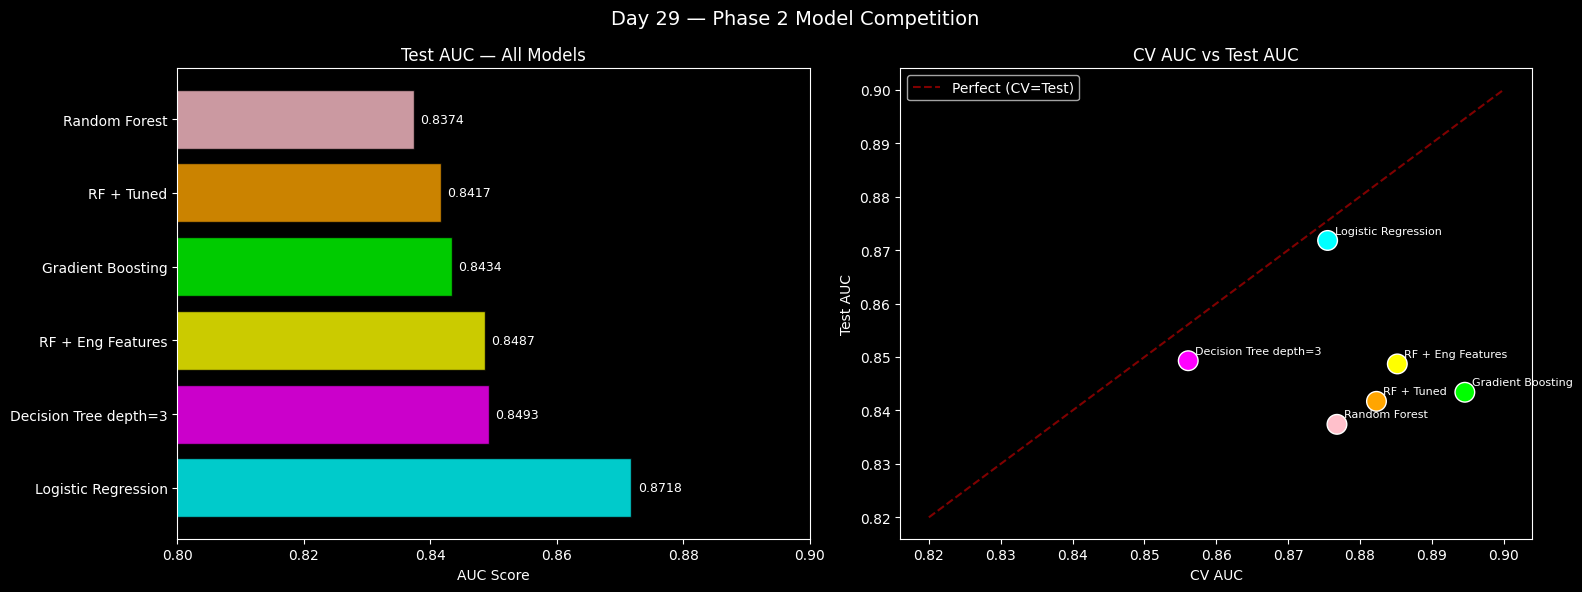

In [ ]:
print("=" * 60)
print("    BEST MODEL COMPETITION — ALL APPROACHES")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression (Day 16)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(random_state=42, max_iter=1000)),
        ]
    ),
    "Decision Tree depth=3 (Day 19)": DecisionTreeClassifier(
        max_depth=3, random_state=42
    ),
    "Random Forest (Day 20)": RandomForestClassifier(
        n_estimators=100, random_state=42, oob_score=True
    ),
    "RF + Eng Features (Day 22)": RandomForestClassifier(
        n_estimators=100, min_samples_leaf=4, random_state=42
    ),
    "RF + Tuned (Day 24)": RandomForestClassifier(
        n_estimators=50,
        max_depth=None,
        min_samples_leaf=4,
        min_samples_split=2,
        random_state=42,
    ),
    "Gradient Boosting (Day 25)": GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_auc = cross_val_score(model, X_train, y_train, cv=skf, scoring="roc_auc").mean()
    test_auc = roc_auc_score(y_test, y_prob)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    results.append(
        {
            "Model": name,
            "CV_AUC": round(cv_auc, 4),
            "Test_AUC": round(test_auc, 4),
            "Test_Acc": round(test_acc, 4),
            "F1": round(test_f1, 4),
            "Gap": round(cv_auc - test_auc, 4),
        }
    )
    print(f"✅ {name}")

results_df = pd.DataFrame(results).sort_values("Test_AUC", ascending=False)
print(f"\n{'Model':<35} {'CV_AUC':<10} {'Test_AUC':<10} {'Acc':<8} {'F1':<8} {'Gap'}")
print("-" * 80)
for _, row in results_df.iterrows():
    print(
        f"{row['Model']:<35} {row['CV_AUC']:<10} {row['Test_AUC']:<10} "
        f"{row['Test_Acc']:<8} {row['F1']:<8} {row['Gap']}"
    )

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Day 29 — Phase 2 Model Competition", fontsize=14)

colors = ["cyan", "magenta", "yellow", "lime", "orange", "pink"]
short_names = [n.split("(")[0].strip() for n in results_df["Model"]]

axes[0].barh(
    short_names,
    results_df["Test_AUC"],
    color=colors[: len(results_df)],
    edgecolor="black",
    alpha=0.8,
)
axes[0].set_title("Test AUC — All Models")
axes[0].set_xlabel("AUC Score")
axes[0].set_xlim(0.80, 0.90)
for i, v in enumerate(results_df["Test_AUC"]):
    axes[0].text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

axes[1].scatter(
    results_df["CV_AUC"],
    results_df["Test_AUC"],
    c=colors[: len(results_df)],
    s=200,
    edgecolors="white",
    zorder=5,
)
axes[1].plot([0.82, 0.90], [0.82, 0.90], "r--", alpha=0.5, label="Perfect (CV=Test)")
for i, name in enumerate(short_names):
    axes[1].annotate(
        name,
        (results_df["CV_AUC"].iloc[i], results_df["Test_AUC"].iloc[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )
axes[1].set_title("CV AUC vs Test AUC")
axes[1].set_xlabel("CV AUC")
axes[1].set_ylabel("Test AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Phase 2 Key Insights & Lessons Learned

      PHASE 2 KEY INSIGHTS & LESSONS LEARNED

LESSON 1 — ALWAYS START SIMPLE
  Logistic Regression beat ALL tree models on Titanic!
  Complex models need more data to shine (10k+ rows)
  Simple model + good features > complex model + raw features

LESSON 2 — FEATURE ENGINEERING IS THE MOST IMPACTFUL STEP
  Title extraction: Mrs 79.4% survival — goldmine feature!
  FareLog beat raw Fare in all selection methods
  LR improved +3.9% test accuracy from feature engineering alone
  HasCabin: 77% missing values → turned into useful binary feature

LESSON 3 — CV AUC ≠ TEST AUC
  Gradient Boosting: CV=0.895 but Test=0.843 (gap=0.051!)
  Logistic Regression: CV=0.876, Test=0.872 (gap=0.004)
  Always hold out a test set — CV can be optimistic

LESSON 4 — SHAP BEATS RF FEATURE IMPORTANCE
  RF importance: Fare=0.133 (top) — inflated by Pclass correlation
  SHAP: Title_Mr=0.109, Sex=0.107 (top) — honest attribution
  Female SHAP +0.149 vs male -0.086 = 23.5% gender swing

LESSON 5 — IMBALANCED DATA 

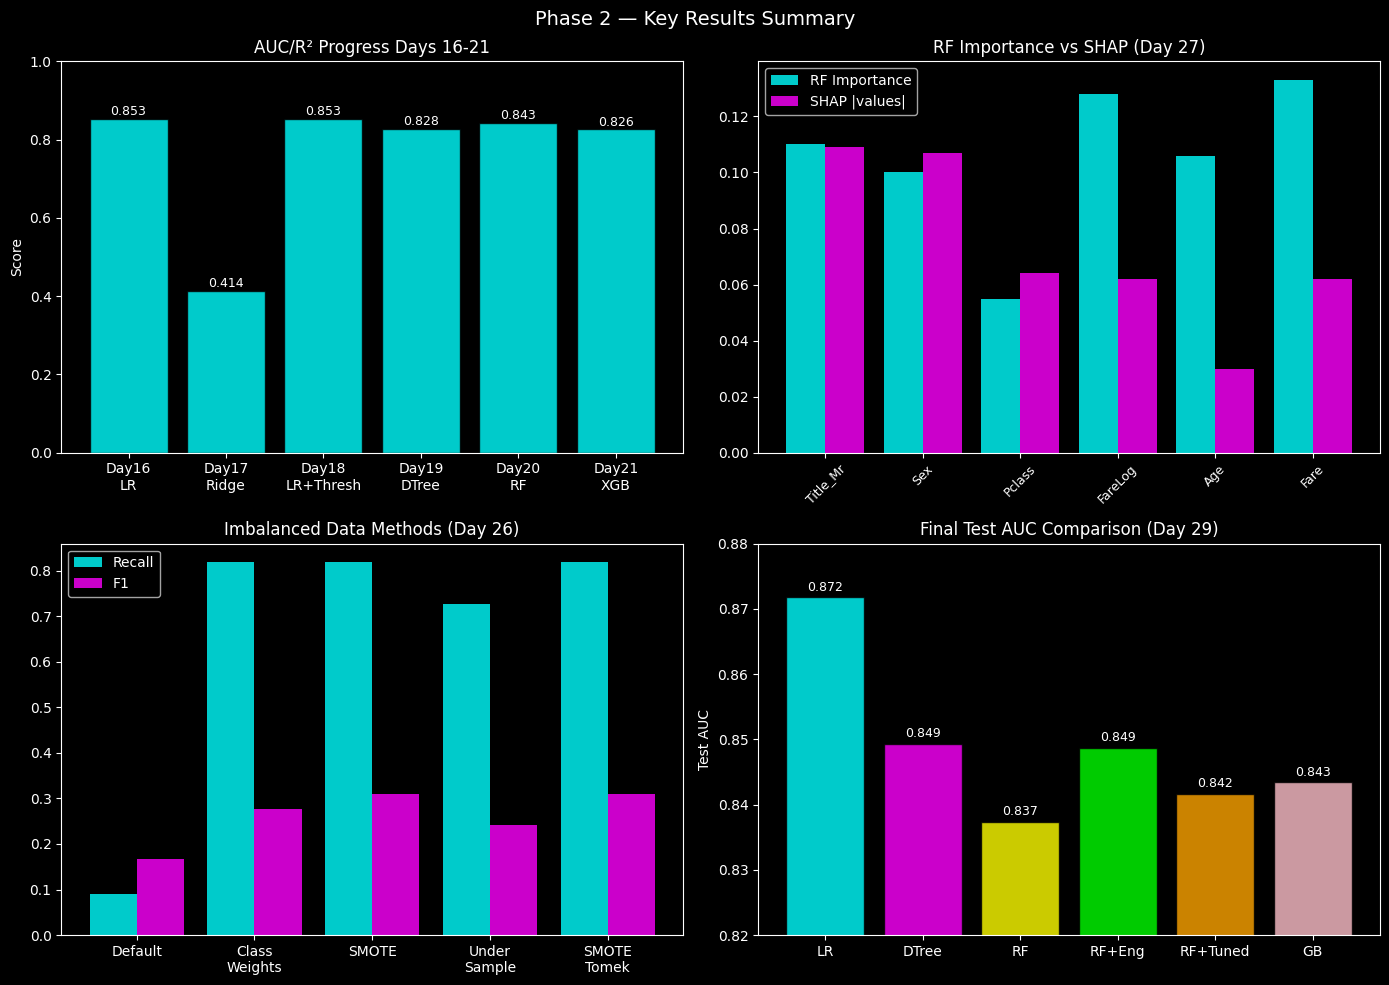

In [ ]:
print("=" * 60)
print("      PHASE 2 KEY INSIGHTS & LESSONS LEARNED")
print("=" * 60)
print("""
LESSON 1 — ALWAYS START SIMPLE
  Logistic Regression beat ALL tree models on Titanic!
  Complex models need more data to shine (10k+ rows)
  Simple model + good features > complex model + raw features

LESSON 2 — FEATURE ENGINEERING IS THE MOST IMPACTFUL STEP
  Title extraction: Mrs 79.4% survival — goldmine feature!
  FareLog beat raw Fare in all selection methods
  LR improved +3.9% test accuracy from feature engineering alone
  HasCabin: 77% missing values → turned into useful binary feature

LESSON 3 — CV AUC ≠ TEST AUC
  Gradient Boosting: CV=0.895 but Test=0.843 (gap=0.051!)
  Logistic Regression: CV=0.876, Test=0.872 (gap=0.004)
  Always hold out a test set — CV can be optimistic

LESSON 4 — SHAP BEATS RF FEATURE IMPORTANCE
  RF importance: Fare=0.133 (top) — inflated by Pclass correlation
  SHAP: Title_Mr=0.109, Sex=0.107 (top) — honest attribution
  Female SHAP +0.149 vs male -0.086 = 23.5% gender swing

LESSON 5 — IMBALANCED DATA NEEDS SPECIAL TREATMENT
  Default model: minority recall = 9.1% (catches 1 in 11!)
  SMOTE: recall = 81.8% (catches 9 in 11!)
  Always use F1/Recall, not accuracy, for imbalanced data

LESSON 6 — BIAS-VARIANCE TRADEOFF IS REAL
  Decision Tree depth=15: train=98%, test=79% (overfitting!)
  depth=3: sweet spot — train=83%, test=80% (small gap)
  Random Forest reduces variance by averaging many trees

LESSON 7 — STATIONARITY BEFORE ARIMA
  Original time series: p=0.995 — non-stationary!
  After first difference: p=0.0001 — stationary ✅
  ARIMA without seasonal terms → flat forecast → use SARIMA

LESSON 8 — THRESHOLD IS A BUSINESS DECISION
  Default threshold=0.5 rarely optimal for imbalanced data
  Fraud: lower threshold (catch everything, false alarms are cheap)
  Spam: higher threshold (false positives = blocked real emails)
  Best threshold depends on cost-benefit analysis, not just F1
""")

# Final metrics visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Phase 2 — Key Results Summary", fontsize=14)

# 1 — Model AUC progression
days = [
    "Day16\nLR",
    "Day17\nRidge",
    "Day18\nLR+Thresh",
    "Day19\nDTree",
    "Day20\nRF",
    "Day21\nXGB",
]
aucs = [0.853, 0.414, 0.853, 0.828, 0.843, 0.826]
axes[0, 0].bar(days, aucs, color="cyan", edgecolor="black", alpha=0.8)
axes[0, 0].set_title("AUC/R² Progress Days 16-21")
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate(aucs):
    axes[0, 0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# 2 — Feature importance comparison (RF vs SHAP)
features_plot = ["Title_Mr", "Sex", "Pclass", "FareLog", "Age", "Fare"]
rf_imp = [0.110, 0.100, 0.055, 0.128, 0.106, 0.133]
shap_imp = [0.109, 0.107, 0.064, 0.062, 0.030, 0.062]
x = np.arange(len(features_plot))
axes[0, 1].bar(x - 0.2, rf_imp, 0.4, label="RF Importance", color="cyan", alpha=0.8)
axes[0, 1].bar(
    x + 0.2, shap_imp, 0.4, label="SHAP |values|", color="magenta", alpha=0.8
)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(features_plot, rotation=45, fontsize=9)
axes[0, 1].set_title("RF Importance vs SHAP (Day 27)")
axes[0, 1].legend()

# 3 — Imbalanced data comparison
methods = ["Default", "Class\nWeights", "SMOTE", "Under\nSample", "SMOTE\nTomek"]
recalls = [0.091, 0.818, 0.818, 0.727, 0.818]
f1s = [0.167, 0.277, 0.310, 0.242, 0.310]
x3 = np.arange(len(methods))
axes[1, 0].bar(x3 - 0.2, recalls, 0.4, label="Recall", color="cyan", alpha=0.8)
axes[1, 0].bar(x3 + 0.2, f1s, 0.4, label="F1", color="magenta", alpha=0.8)
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(methods)
axes[1, 0].set_title("Imbalanced Data Methods (Day 26)")
axes[1, 0].legend()

# 4 — Phase 2 final model comparison
model_names = ["LR", "DTree", "RF", "RF+Eng", "RF+Tuned", "GB"]
test_aucs = [0.8718, 0.8493, 0.8374, 0.8487, 0.8417, 0.8434]
colors4 = ["cyan", "magenta", "yellow", "lime", "orange", "pink"]
axes[1, 1].bar(model_names, test_aucs, color=colors4, edgecolor="black", alpha=0.8)
axes[1, 1].set_title("Final Test AUC Comparison (Day 29)")
axes[1, 1].set_ylabel("Test AUC")
axes[1, 1].set_ylim(0.82, 0.88)
for i, v in enumerate(test_aucs):
    axes[1, 1].text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Key Takeaways — Day 29 Phase 2 Review 🎯

### Phase 2 Final Standings (Test AUC)
| Rank | Model | Day | Test AUC | Key Lesson |
|---|---|---|---|---|
| 🥇 | Logistic Regression | 16 | 0.872 | Simple + features wins! |
| 🥈 | Decision Tree depth=3 | 19 | 0.849 | Sweet spot at depth=3 |
| 🥈 | RF + Eng Features | 22 | 0.849 | Feature eng matters! |
| 4th | Gradient Boosting | 25 | 0.843 | Overfit — CV optimistic |
| 5th | RF + Tuned | 24 | 0.842 | Tuning helps but not enough |
| 6th | Random Forest | 20 | 0.837 | Baseline RF |

### 8 Key Lessons from Phase 2
1. **Always start simple** — LR beat all tree models on 891 rows!
2. **Feature engineering is #1** — +3.9% from Title/FareLog/HasCabin
3. **CV AUC ≠ Test AUC** — GB gap=0.051 (optimistic CV!)
4. **SHAP > RF importance** — Fare inflated by correlation
5. **Imbalanced data** — SMOTE: recall 9.1% → 81.8%!
6. **Bias-variance** — depth=3 sweet spot, depth=15 overfits
7. **Stationarity first** — ARIMA needs differenced series
8. **Threshold = business decision** — cost-benefit, not just F1

### What We Built in Phase 2
- 6 ML algorithms from scratch and with sklearn
- Feature engineering pipeline (Title, FareLog, HasCabin, Age²)
- Hyperparameter tuning (GridSearch, RandomSearch, Optuna)
- Model explainability (SHAP, waterfall, beeswarm)
- Imbalanced data handling (SMOTE, class weights)
- Time series analysis (decomposition, ADF, ARIMA)
- Clustering (K-Means, DBSCAN, PCA)

### Phase 2 Best Numbers
- Best Test AUC: **0.872** (Logistic Regression)
- Best SMOTE recall: **81.8%** (vs 9.1% default)
- Biggest feature gain: **+3.9%** test accuracy from engineering
- SHAP gender swing: **23.5%** (female +0.149 vs male -0.086)
- Time series MAPE: **15.8%** (ARIMA — needs SARIMA for seasonality)

### Next Up — Project 1 (Days 30-35)!
Build a complete end-to-end ML application:
- Full pipeline with all Phase 2 techniques
- Streamlit web application
- Deployed and shareable
- Added to portfolio!